# **Практическая работа №10. Разведочный анализ, предобработка данных и обучение моделей классификации**

*(на примере датасета Bank Marketing)*

---

## ****Введение****

**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).

**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.

**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и **экспериментально проверять** гипотезы
- Создавать новые признаки (Feature Engineering)
- **Сравнивать все изученные методы классификации**
- **Выбирать лучшие модели и оптимизировать их гиперпараметры с помощью GridSearchCV**
- **Анализировать влияние комбинаций признаков на качество модели**

---

## ****Часть 1. Настройка окружения****

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report)

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Отбор признаков
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from itertools import combinations

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## ****Часть 2. Загрузка и первичный осмотр данных****

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### ****Задание 2.1. Загрузите датасет****

In [3]:
# Загрузка датасета Bank Marketing
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

# ВАЖНО: В этом датасете пропуски записаны как "unknown"
# Заменяем их на NaN, чтобы isna() корректно их определял
bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### ****Задание 2.2. Изучите структуру данных****

**1. Выведите размерность датасета:**

In [4]:
bank.shape


(4521, 17)

**2. Отобразите первые 10 строк датасета**

In [5]:
bank.head(10)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,NaN,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,NaN,14,may,57,2,-1,0,NaN,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**3. Выведите информацию о типах данных и пропусках**

In [6]:
bank.info()


<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4483 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4334 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    3197 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   816 non-null    str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


**4. Выведите статистику числовых признаков**

In [7]:
bank.describe()


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**5. Выведите названия всех столбцов в виде списка строк**

In [8]:
list(bank.columns)


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### ****Задание 2.3. Ответьте на вопросы****

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---

**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** 4521 запись

**Вопрос 2:** Сколько признаков (столбцов)?

**Ответ:** 17 столбцов

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?

**Ответ:** Целевая переменная - y. Она показывает открыл клиент вклад или нет

**Вопрос 4:** Какие типы данных преобладают - числовые или категориальные?

**Ответ:** Категориальных признаков больше, чем числовых



### ****Описание столбцов датасета Bank Marketing****

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## ****Часть 3. Разведочный анализ данных (EDA)****

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### ****3.1. Анализ целевой переменной (баланс классов)****

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [9]:
# Создаём числовую версию целевой переменной в столбце target
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

In [10]:
bank['y'].value_counts()


y
no     4000
yes     521
Name: count, dtype: int64

**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?

**Ответ:** 521 клиент открыл депозит, а 4000 клиентов не открыли

---

**Визуализируйте распределения классов графически (постройте столбчатую (barplot) или круговую (pie chart) диаграмму)**


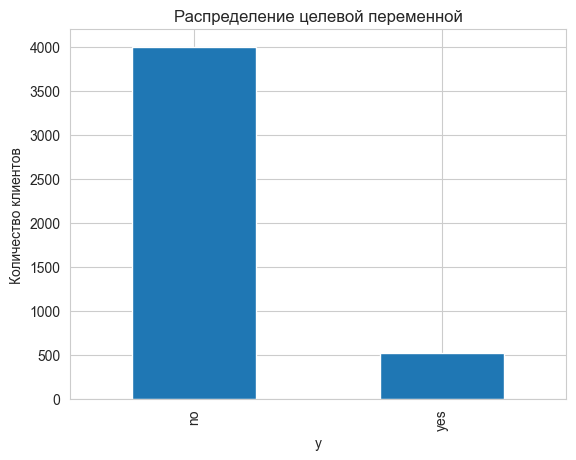

In [11]:
bank['y'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('y')
plt.ylabel('Количество клиентов')
plt.show()


**Вычислите процент клиентов, открывших вклад**


In [12]:
print((bank['y'] == 'yes').mean() * 100)


11.523999115239992


**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** Классы сильно несбалансированы. Сильно преобладает класс no: 4000 против 521

---


### ****3.2. Анализ пропущенных значений****

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [13]:
bank.isna().sum()


age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
target          0
dtype: int64

**Вычислите процент пропущенных значений в каждом столбце датасета**

In [14]:
missing_percent = bank.isna().sum() / len(bank) * 100
missing_percent.sort_values(ascending=False)


poutcome     81.950896
contact      29.285556
education     4.136253
job           0.840522
age           0.000000
default       0.000000
balance       0.000000
housing       0.000000
loan          0.000000
marital       0.000000
day           0.000000
month         0.000000
campaign      0.000000
duration      0.000000
pdays         0.000000
previous      0.000000
y             0.000000
target        0.000000
dtype: float64

**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

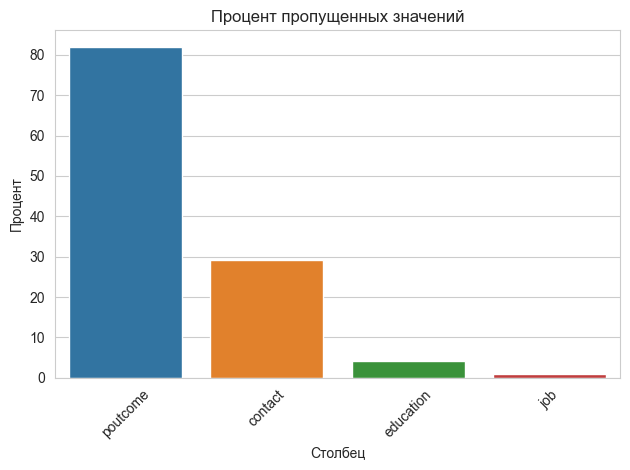

In [15]:
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({'Столбец': missing_percent.index, 'Процент': missing_percent.values})
sns.barplot(data=missing_df, x='Столбец', y='Процент', hue='Столбец', legend=False)
plt.xticks(rotation=45)
plt.title('Процент пропущенных значений')
plt.tight_layout()
plt.show()


**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?

**Ответ:** Больше всего пропусков в poutcome - около 82% данных, затем в contact - около 29%. Поэтому при удалении всех строк с пропусками потеряется очень большая часть датасета

---


### ****3.3. Анализ числовых признаков****

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).

**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

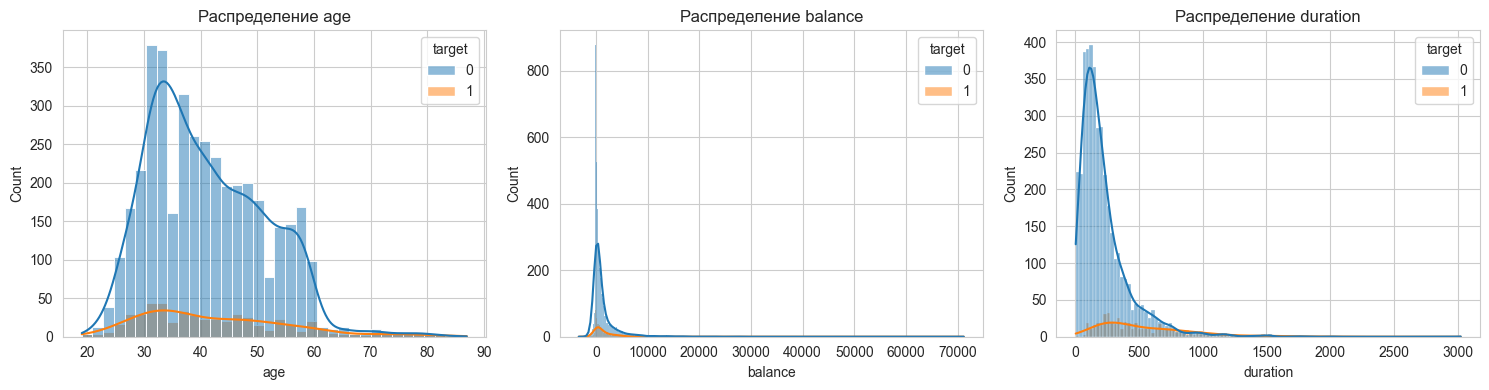

In [16]:
numeric_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    sns.histplot(data=bank, x=col, hue='target', kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()


*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?

**Ответ:** Сильнее всего различается duration: у клиентов, которые открыли вклад звонки в среднем дольше. balance тоже отличается, а по age разница заметна меньше

---


### ****Задание 3.4. Анализ категориальных признаков****

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).

**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

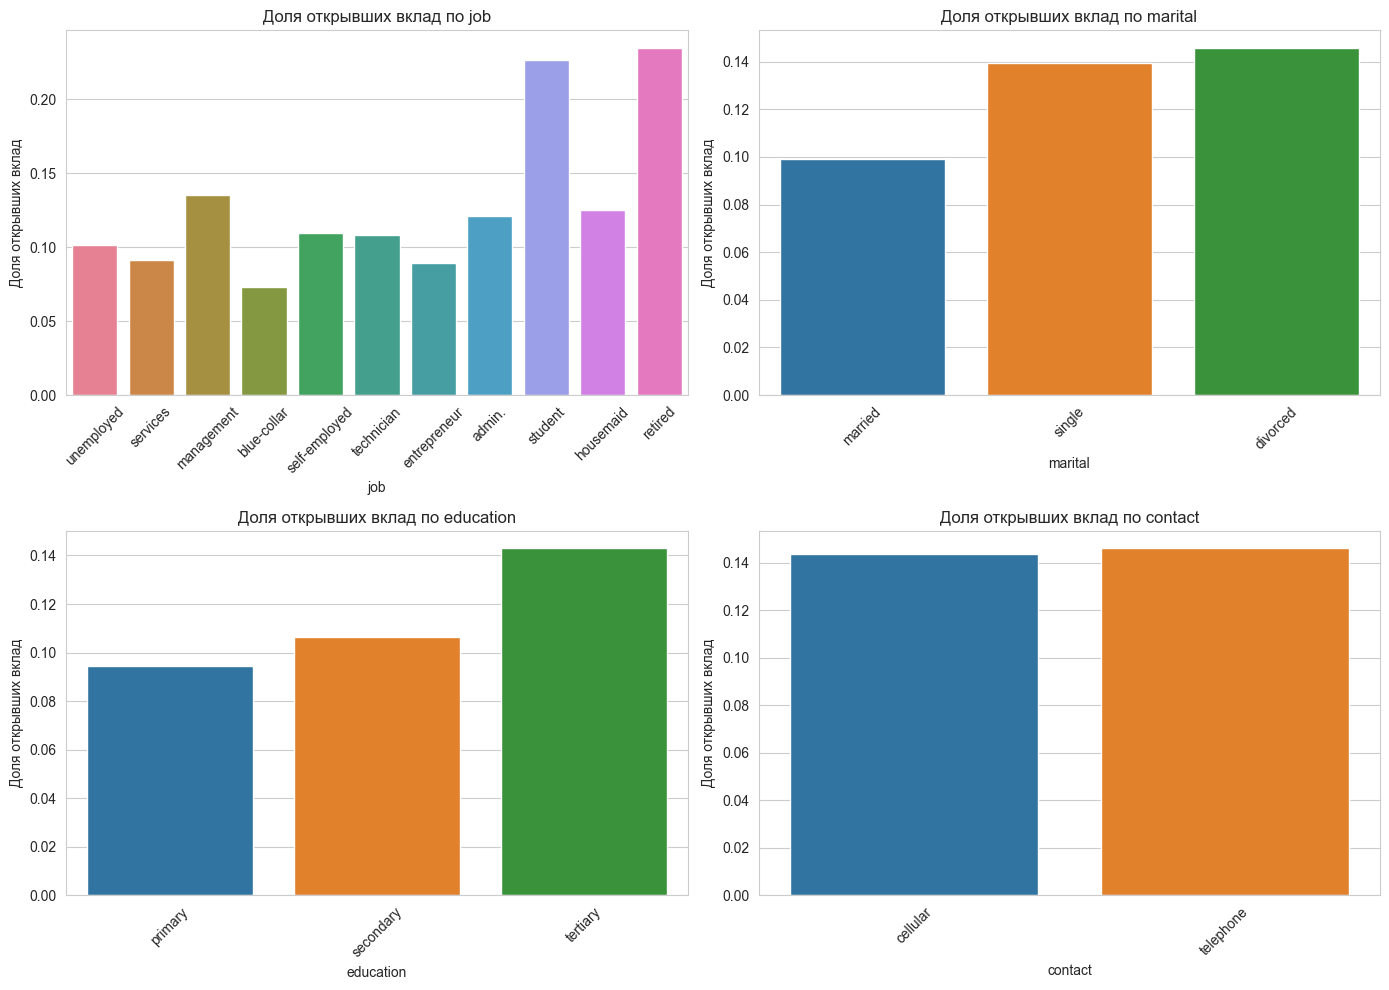

In [17]:
cat_features = ['job', 'marital', 'education', 'contact']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.barplot(data=bank, x=col, y='target', hue=col, ax=axes[i], legend=False, errorbar=None)
    axes[i].set_title(f'Доля открывших вклад по {col}')
    axes[i].set_ylabel('Доля открывших вклад')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

**Ответьте на вопросы:**

**Вопрос:** Люди каких профессий чаще открывают депозит?

**Ответ:** По доле открывших вклад чаще всего это клиенты из категорий retired и student

**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?

**Ответ:** Да. Доля открывших вклад отличается для разных семейных положений и у single она выше

**Вопрос:** Какой тип связи (`contact`) наиболее эффективен?

**Ответ:** По доле открывших вклад немного выше результат у telephone, а у unknown он заметно ниже

**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?

**Ответ:** Чаще встречаются положительные результаты среди retired и student, а также среди single и клиентов с более высоким уровнем образования

---


### ****Задание 3.5. Анализ связей между признаками (Boxplot)****

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

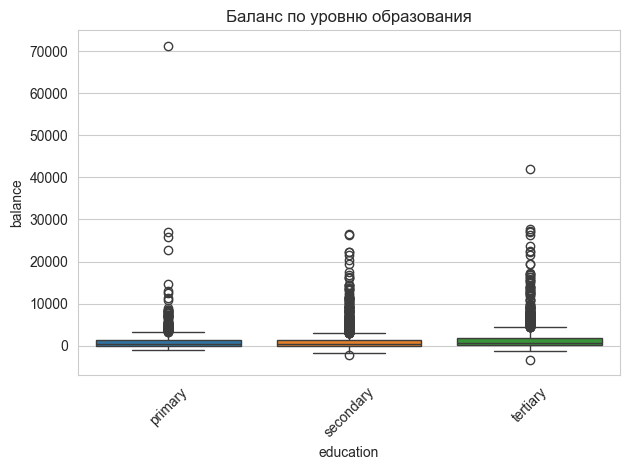

In [18]:
sns.boxplot(data=bank, x='education', y='balance', hue='education', legend=False)
plt.title('Баланс по уровню образования')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Вопрос:** Различается ли баланс у клиентов с разным образованием?

**Ответ:** Да, распределение баланса у групп с разным образованием отличается

---


### ****Задание 3.6. Группировка данных****

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [19]:
job_stats = bank.groupby('job').agg(
    средний_баланс=('balance', 'mean'),
    доля_вклада=('target', 'mean')
).sort_values('доля_вклада', ascending=False)

job_stats


,средний_баланс,доля_вклада
job,,
retired,2319.191304,0.234783
student,1543.821429,0.226190
management,1766.928793,0.135191
housemaid,2083.803571,0.125000
admin.,1226.736402,0.121339
self-employed,1392.409836,0.109290
technician,1330.996094,0.108073
unemployed,1089.421875,0.101562
services,1103.956835,0.091127


**Вычислите долю открывших депозит по уровню образования**

In [20]:
bank.groupby('education')['target'].mean().sort_values(ascending=False)


education
tertiary     0.142963
secondary    0.106245
primary      0.094395
Name: target, dtype: float64

---

## ****Часть 4. Формулировка гипотез и план экспериментов****

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).

На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### **Мои гипотезы:**


| № | Наблюдение из EDA | Гипотеза | Как проверить | Метрика для сравнения |
|---|-------------------|----------|---------------|----------------------|
| 1 | Доля открывших вклад различается по `job` | Добавить бинарный признак `job_retired_student` для клиентов из категорий `retired` и `student` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 2 | Доля открывших вклад различается по `education` | Добавить бинарный признак `higher_education` для клиентов с `tertiary` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| 3 | Доля открывших вклад различается по `contact` | Добавить бинарный признак `cellular_contact` для клиентов с типом связи `cellular` | Добавить признак, сравнить accuracy | Accuracy, F1 |

**Примеры формулировок (для ориентира):**

| Наблюдение | Гипотеза | Как проверить | Метрика |
|------------|----------|---------------|---------|
| `duration` сильно различается у классов | Признак важен для предсказания | Сравнить accuracy с `duration` и без него | Accuracy, F1 |
| `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| В `job` есть пропуски | Факт пропуска может быть информативен | Создать `job_unknown`, сравнить accuracy | Accuracy, F1 |
| Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |

> 📚 **Подсказка:** Методология проверки гипотез через эксперименты подробно разобрана в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

---


## ****Часть 5. Сравнение методов классификации****

> 📚 **Подсказка:** Различные методы классификации (логистическая регрессия, деревья решений, ансамбли, SVM, KNN) подробно разбирались на занятиях по supervised learning.

### ****5.1. Расширенная функция оценки модели****

> 📚 **Подсказка:** Базовая функция `evaluate_model()` была создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [21]:
def evaluate_model_advanced(model, X, y, model_name="Model"):
    """
    Расширенная оценка модели с множественными метриками.

    Параметры:
    ----------
    model : sklearn estimator
        Модель для обучения и оценки
    X : DataFrame или array
        Признаки
    y : Series или array
        Целевая переменная
    model_name : str
        Название модели для отображения

    Возвращает:
    -----------
    dict : словарь с метриками
    """
    # 1. Разделение данных (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 2. Масштабирование (ВАЖНО: fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Обучение модели
    model.fit(X_train_scaled, y_train)

    # 4. Предсказание
    y_pred = model.predict(X_test_scaled)

    # 5. Вероятности (если модель поддерживает)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = None

    # 6. Расчёт метрик
    results = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc
    }

    return results, y_test, y_pred, y_proba

### ****5.2. Простая функция оценки (для быстрых экспериментов)****

In [22]:
def evaluate_model(X, y):
    """
    Быстрая оценка модели логистической регрессии.
    Возвращает только accuracy.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### ****5.3. Подготовка данных для baseline****

In [23]:
# Выбираем числовые признаки
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

df_baseline = bank[numeric_cols + ['target']].dropna()
X_baseline = df_baseline[numeric_cols]
y_baseline = df_baseline['target']

print(f'Размер X: {X_baseline.shape}')
print(f'Размер y: {y_baseline.shape}')


Размер X: (4521, 7)
Размер y: (4521,)


### ****5.4. Задание: Сравните ВСЕ методы классификации****

**Создайте словарь со всеми моделями:**

In [24]:
# Словарь моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

**Обучите все модели и соберите результаты:**

In [25]:
comparison_results = []

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(model, X_baseline, y_baseline, name)
    comparison_results.append(results)
    roc_text = f"{results['roc_auc']:.4f}" if results['roc_auc'] is not None else 'N/A'
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {roc_text}")

df_comparison = pd.DataFrame(comparison_results)
df_comparison = df_comparison.sort_values('f1', ascending=False)
df_comparison


Logistic Regression       | Accuracy: 0.8862 | F1: 0.2370 | ROC-AUC: 0.8162
Decision Tree             | Accuracy: 0.8475 | F1: 0.3365 | ROC-AUC: 0.6252
Random Forest             | Accuracy: 0.8729 | F1: 0.2857 | ROC-AUC: 0.8449
Gradient Boosting         | Accuracy: 0.8807 | F1: 0.3494 | ROC-AUC: 0.8491
AdaBoost                  | Accuracy: 0.8807 | F1: 0.2800 | ROC-AUC: 0.8366
SVM                       | Accuracy: 0.8873 | F1: 0.1639 | ROC-AUC: 0.7408
KNN                       | Accuracy: 0.8917 | F1: 0.3718 | ROC-AUC: 0.7192
Naive Bayes               | Accuracy: 0.8575 | F1: 0.3768 | ROC-AUC: 0.8009


,model_name,accuracy,precision,recall,f1,roc_auc
7,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862
6,KNN,0.891713,0.557692,0.278846,0.371795,0.719167
3,Gradient Boosting,0.880663,0.467742,0.278846,0.349398,0.849101
1,Decision Tree,0.847514,0.336538,0.336538,0.336538,0.625198
2,Random Forest,0.872928,0.403509,0.221154,0.285714,0.844947
4,AdaBoost,0.880663,0.456522,0.201923,0.280000,0.836604
0,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
5,SVM,0.887293,0.555556,0.096154,0.163934,0.740787


<details>
<summary><b>Подсказка (код):</b></summary>

In [26]:
df_comparison


,model_name,accuracy,precision,recall,f1,roc_auc
7,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862
6,KNN,0.891713,0.557692,0.278846,0.371795,0.719167
3,Gradient Boosting,0.880663,0.467742,0.278846,0.349398,0.849101
1,Decision Tree,0.847514,0.336538,0.336538,0.336538,0.625198
2,Random Forest,0.872928,0.403509,0.221154,0.285714,0.844947
4,AdaBoost,0.880663,0.456522,0.201923,0.280000,0.836604
0,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
5,SVM,0.887293,0.555556,0.096154,0.163934,0.740787


</details>

### ****5.5. Создайте DataFrame с результатами и визуализируйте****

In [27]:
df_comparison = pd.DataFrame(comparison_results)
df_comparison = df_comparison.sort_values('f1', ascending=False)
df_comparison


,model_name,accuracy,precision,recall,f1,roc_auc
7,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862
6,KNN,0.891713,0.557692,0.278846,0.371795,0.719167
3,Gradient Boosting,0.880663,0.467742,0.278846,0.349398,0.849101
1,Decision Tree,0.847514,0.336538,0.336538,0.336538,0.625198
2,Random Forest,0.872928,0.403509,0.221154,0.285714,0.844947
4,AdaBoost,0.880663,0.456522,0.201923,0.280000,0.836604
0,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
5,SVM,0.887293,0.555556,0.096154,0.163934,0.740787


**Постройте визуализацию сравнения моделей:**

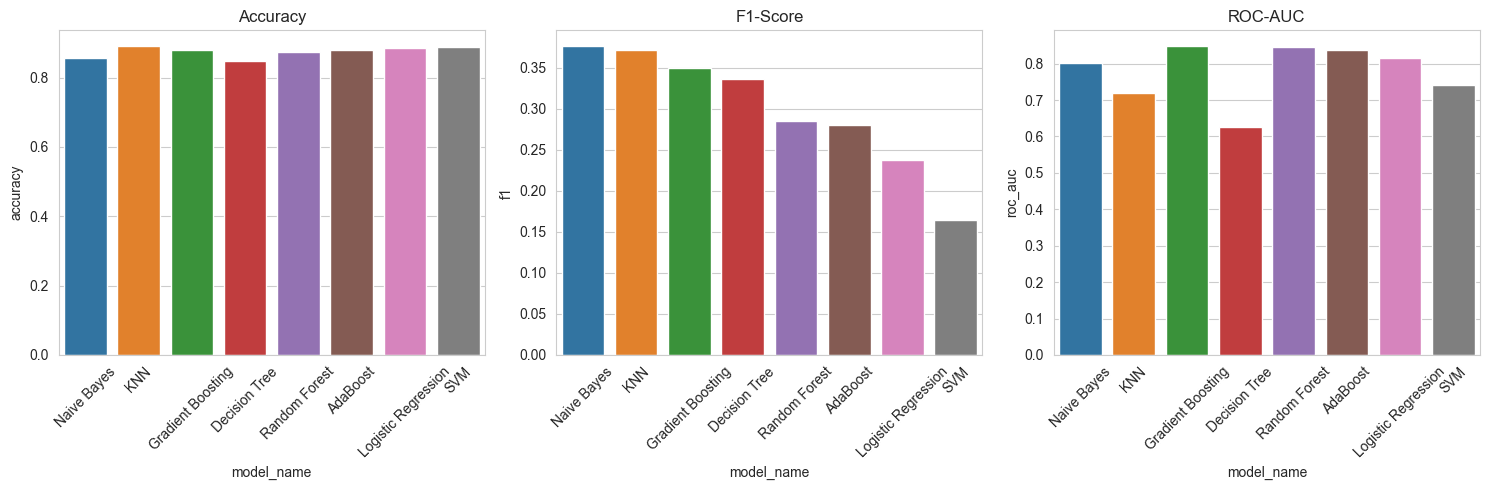

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    sns.barplot(data=df_comparison, x='model_name', y=metric, hue='model_name', ax=axes[i], legend=False)
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### ****5.6. Ответьте на вопросы****

**Вопрос:** Какие 3 модели показали лучший результат по F1-Score?

**Ответ:** Это три модели, которые стоят первыми в таблице после сортировки по F1-Score

**Вопрос:** Почему мы ориентируемся на F1-Score, а не на Accuracy? (Подсказка: вспомните баланс классов)

**Ответ:** Потому что классы сильно несбалансированы. Accuracy может быть высокой просто из-за того, что модель часто выбирает класс no. F1-Score лучше показывает, как модель работает именно с положительным классом

**Вопрос:** Какая модель показала лучший ROC-AUC? Что это означает?

**Ответ:** Это модель с самым высоким значением ROC-AUC в таблице. Чем выше ROC-AUC, тем лучше модель разделяет положительный и отрицательный классы при разных порогах

---


## ****Часть 6. Стратегии обработки пропусков****

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### ****6.1. Стратегия A: Удаление строк с пропусками****

In [29]:
# Посмотрим, сколько данных потеряем
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?

**Ответ:** Нет. При удалении строк теряется слишком много данных, поэтому лучше попробовать заполнить пропуски и сохранить записи

---


### ****6.2. Стратегия B: Заполнение модой****

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [30]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome']

for col in cat_cols_with_na:
    if df_filled[col].isna().sum() > 0:
        df_filled[col] = df_filled[col].fillna(df_filled[col].mode()[0])

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")


Пропусков после заполнения: 0


### ****6.3. Стратегия C: Создание признаков из пропусков****

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [50]:
df_fe = bank.copy()

# Пример:
# df_fe['job_unknown'] = bank['job'].isna().astype(int)
# df_fe['education_unknown'] = bank['education'].isna().astype(int)
# df_fe['contact_unknown'] = bank['contact'].isna().astype(int)
# df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

# ВАШ КОД
df_fe['job_unknown'] = df_fe['job'].isna().astype(int)
df_fe['education_unknown'] = df_fe['education'].isna().astype(int)
df_fe['contact_unknown'] = df_fe['contact'].isna().astype(int)
df_fe['poutcome_unknown'] = df_fe['poutcome'].isna().astype(int)

---

## ****Часть 7. Feature Engineering и отбор признаков****

> 📚 **Подсказка:** Создание новых признаков на основе анализа данных описано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****7.1. Создание новых признаков****

**Создайте следующие признаки на основе гипотез из EDA:**

In [32]:
df_fe = bank.copy()

# 1. Был ли клиент контактирован ранее (pdays != -1)
df_fe['was_contacted'] = (bank['pdays'] != -1).astype(int)

# 2. Положительный баланс
df_fe['has_positive_balance'] = (bank['balance'] > 0).astype(int)

# 3. Признаки из пропусков (ДО заполнения!)
df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)

# Теперь заполняем пропуски
for col in ['job', 'education', 'contact', 'poutcome']:
    if df_fe[col].isna().sum() > 0:
        mode_value = df_fe[col].mode()[0]
        df_fe[col] = df_fe[col].fillna(mode_value)

print("Созданные признаки:")
print(df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown']].head(10))

Созданные признаки:
   was_contacted  has_positive_balance  job_unknown  education_unknown  \
0              0                     1            0                  0   
1              1                     1            0                  0   
2              1                     1            0                  0   
3              0                     1            0                  0   
4              0                     0            0                  0   
5              1                     1            0                  0   
6              1                     1            0                  0   
7              0                     1            0                  0   
8              0                     1            0                  0   
9              1                     0            0                  0   

   contact_unknown  
0                0  
1                0  
2                0  
3                1  
4                1  
5                0  
6                0

**Добавьте свои признаки на основе ваших гипотез:**

In [ ]:
df_fe['job_retired_student'] = df_fe['job'].isin(['retired', 'student']).astype(int)
df_fe['higher_education'] = (df_fe['education'] == 'tertiary').astype(int)
df_fe['cellular_contact'] = (df_fe['contact'] == 'cellular').astype(int)

print(df_fe[['job_retired_student', 'higher_education', 'cellular_contact']].head())


   job_retired_student  higher_education  cellular_contact
0                    0                 0                 1
1                    0                 0                 1
2                    0                 1                 1
3                    0                 1                 1
4                    0                 0                 1


### ****7.2. Систематический перебор комбинаций признаков****

> **Цель:** Определить, какие признаки улучшают модель, а какие вносят шум.

**Определите базовый набор признаков и признаки для тестирования:**

In [34]:
base_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown',
                'education_unknown', 'contact_unknown', 'job_retired_student',
                'higher_education', 'cellular_contact']

X_base = df_fe[base_features]
y = df_fe['target']

accuracy_base = evaluate_model(X_base, y)
print(f'Базовая модель ({len(base_features)} признаков): Accuracy = {accuracy_base:.4f}')


Базовая модель (7 признаков): Accuracy = 0.8862


**Протестируйте добавление каждого нового признака по отдельности:**

In [35]:
feature_results = []

for feature in new_features:
    X = df_fe[base_features + [feature]]
    accuracy = evaluate_model(X, y)
    feature_results.append([feature, accuracy])
    print(f'+ {feature}: Accuracy = {accuracy:.4f}')

feature_comparison = pd.DataFrame(feature_results, columns=['Признак', 'Accuracy'])
feature_comparison


+ was_contacted: Accuracy = 0.8917
+ has_positive_balance: Accuracy = 0.8862
+ job_unknown: Accuracy = 0.8862
+ education_unknown: Accuracy = 0.8862
+ contact_unknown: Accuracy = 0.8818
+ job_retired_student: Accuracy = 0.8851
+ higher_education: Accuracy = 0.8906
+ cellular_contact: Accuracy = 0.8862


,Признак,Accuracy
0,was_contacted,0.891713
1,has_positive_balance,0.886188
2,job_unknown,0.886188
3,education_unknown,0.886188
4,contact_unknown,0.881768
5,job_retired_student,0.885083
6,higher_education,0.890608
7,cellular_contact,0.886188


**Вопрос:** Какие признаки улучшили модель? Какие ухудшили (внесли шум)?

**Ответ:** Улучшили модель те признаки, после добавления которых Accuracy стала выше базовой. Те, после которых Accuracy стала ниже, внесли шум. Это видно в таблице сравнения признаков


### ****7.3. Анализ важности признаков с помощью Random Forest****

ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)
             feature  importance
            duration    0.327962
             balance    0.151323
                 age    0.145094
                 day    0.130871
               pdays    0.069215
            campaign    0.055401
            previous    0.030415
    higher_education    0.020506
     contact_unknown    0.016064
 job_retired_student    0.012532
    cellular_contact    0.011362
       was_contacted    0.009201
has_positive_balance    0.008520
   education_unknown    0.008353
         job_unknown    0.003180


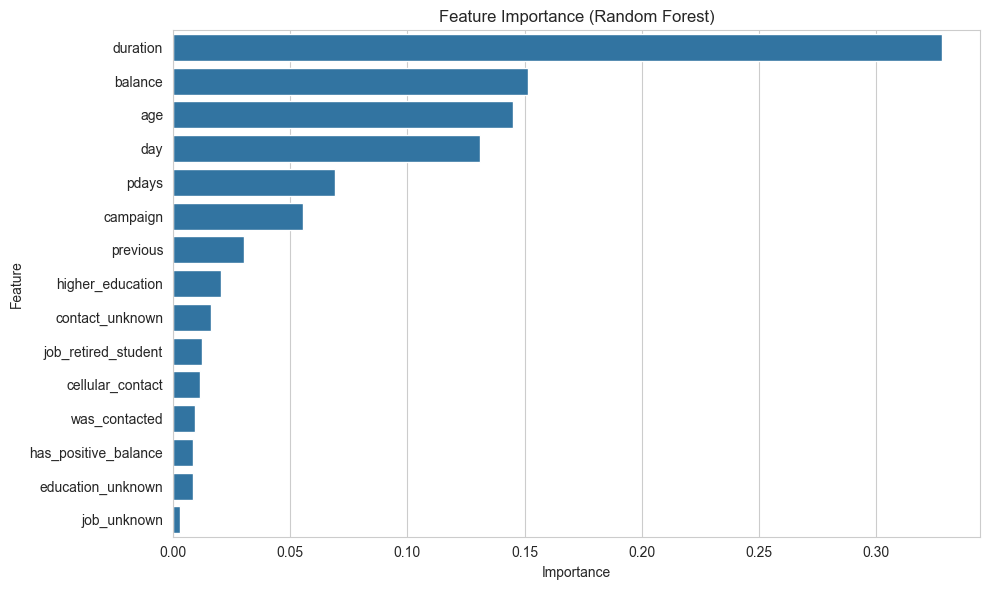

In [36]:
# Соберём все признаки
all_numeric_features = base_features + new_features
X_all = df_fe[all_numeric_features]

# Обучим Random Forest и посмотрим важность признаков
from sklearn.ensemble import RandomForestClassifier

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Обучение
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)")
print("=" * 40)
print(importance_df.to_string(index=False))
print("=" * 40)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### ****7.4. Рекурсивное исключение признаков (RFE)****

> 📚 **Подсказка:** [RFE](https://habr.com/ru/companies/otus/articles/528676/) автоматически отбирает наиболее важные признаки, последовательно удаляя наименее значимые.

In [37]:
from sklearn.feature_selection import RFE

# Применяем RFE для отбора лучших признаков
selector = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=7,  # Отберём 7 лучших признаков
    step=1
)

selector.fit(X_scaled, y)

# Какие признаки отобраны?
selected_features = [f for f, s in zip(all_numeric_features, selector.support_) if s]
rejected_features = [f for f, s in zip(all_numeric_features, selector.support_) if not s]

print("РЕЗУЛЬТАТЫ RFE")
print("=" * 40)
print(f"Отобранные признаки ({len(selected_features)}): {selected_features}")
print(f"Отвергнутые признаки ({len(rejected_features)}): {rejected_features}")
print("=" * 40)

# Сравним accuracy
X_selected = df_fe[selected_features]
accuracy_selected = evaluate_model(X_selected, y)
accuracy_all = evaluate_model(X_all, y)

print(f"\nAccuracy (все {len(all_numeric_features)} признаков): {accuracy_all:.4f}")
print(f"Accuracy (отобранные {len(selected_features)} признаков): {accuracy_selected:.4f}")
print(f"Разница: {accuracy_selected - accuracy_all:+.4f}")

РЕЗУЛЬТАТЫ RFE
Отобранные признаки (7): ['duration', 'campaign', 'pdays', 'was_contacted', 'contact_unknown', 'job_retired_student', 'higher_education']
Отвергнутые признаки (8): ['age', 'balance', 'previous', 'day', 'has_positive_balance', 'job_unknown', 'education_unknown', 'cellular_contact']

Accuracy (все 15 признаков): 0.8862
Accuracy (отобранные 7 признаков): 0.8862
Разница: +0.0000


**Вопрос:** Помог ли отбор признаков улучшить модель? Какие признаки оказались лишними?

**Ответ:** Сравнить это можно по разнице Accuracy в выводе RFE. Лишними оказались признаки, которые RFE не отобрал

---


## ****Часть 8. Кодирование категориальных признаков****

> 📚 **Подсказка:** One-Hot Encoding для категориальных признаков рассматривался в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****8.1. Примените One-Hot Encoding****

In [38]:
# Определяем категориальные столбцы для кодирования
cat_cols_to_encode = ['job', 'marital', 'education', 'default', 'housing',
                       'loan', 'contact', 'month', 'poutcome']

# Применяем One-Hot Encoding
df_encoded = pd.get_dummies(df_fe, columns=cat_cols_to_encode, drop_first=True)

print(f"Было признаков: {df_fe.shape[1]}")
print(f"Стало признаков: {df_encoded.shape[1]}")

Было признаков: 26
Стало признаков: 48


### ****8.2. Подготовьте финальный набор признаков****

In [39]:
# Удаляем целевые переменные и служебные столбцы
cols_to_drop = ['y', 'target']
X_final = df_encoded.drop(columns=cols_to_drop)
y_final = df_encoded['target']

print(f"Финальный размер X: {X_final.shape}")
print(f"Количество признаков: {X_final.shape[1]}")

Финальный размер X: (4521, 46)
Количество признаков: 46


### ****8.3. Сравните модели на расширенном наборе признаков****

In [40]:
print('=' * 70)
print('СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ')
print('=' * 70)

comparison_results_extended = []

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(model, X_final, y_final, name)
    comparison_results_extended.append(results)
    roc_text = f"{results['roc_auc']:.4f}" if results['roc_auc'] is not None else 'N/A'
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {roc_text}")

df_comparison_extended = pd.DataFrame(comparison_results_extended)
df_comparison_extended = df_comparison_extended.sort_values('f1', ascending=False)
df_comparison_extended


СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ
Logistic Regression       | Accuracy: 0.8917 | F1: 0.3951 | ROC-AUC: 0.8918
Decision Tree             | Accuracy: 0.8552 | F1: 0.4229 | ROC-AUC: 0.6840
Random Forest             | Accuracy: 0.8840 | F1: 0.2953 | ROC-AUC: 0.8928
Gradient Boosting         | Accuracy: 0.8928 | F1: 0.4581 | ROC-AUC: 0.8981
AdaBoost                  | Accuracy: 0.8906 | F1: 0.3774 | ROC-AUC: 0.8770
SVM                       | Accuracy: 0.8818 | F1: 0.2621 | ROC-AUC: 0.8749
KNN                       | Accuracy: 0.8851 | F1: 0.2877 | ROC-AUC: 0.7364
Naive Bayes               | Accuracy: 0.8155 | F1: 0.3698 | ROC-AUC: 0.7836


,model_name,accuracy,precision,recall,f1,roc_auc
3,Gradient Boosting,0.892818,0.546667,0.394231,0.458101,0.898054
1,Decision Tree,0.855249,0.390244,0.461538,0.422907,0.683953
0,Logistic Regression,0.891713,0.551724,0.307692,0.395062,0.891794
4,AdaBoost,0.890608,0.545455,0.288462,0.377358,0.877023
7,Naive Bayes,0.815470,0.304348,0.471154,0.369811,0.783630
2,Random Forest,0.883978,0.488889,0.211538,0.295302,0.892778
6,KNN,0.885083,0.500000,0.201923,0.287671,0.736357
5,SVM,0.881768,0.463415,0.182692,0.262069,0.874928


---

## ****Часть 9. Выбор топ-3 моделей****

### ****9.1. Определите топ-3 модели по F1-Score****

In [41]:
# Выберите топ-3 модели из df_comparison_extended
top_3_models = df_comparison_extended.head(3)['model_name'].tolist()

print("ТОП-3 МОДЕЛИ ПО F1-SCORE:")
print("=" * 40)
for i, model_name in enumerate(top_3_models, 1):
    row = df_comparison_extended[df_comparison_extended['model_name'] == model_name].iloc[0]
    print(f"{i}. {model_name}: F1 = {row['f1']:.4f}, ROC-AUC = {row['roc_auc']:.4f}")
print("=" * 40)

ТОП-3 МОДЕЛИ ПО F1-SCORE:
1. Gradient Boosting: F1 = 0.4581, ROC-AUC = 0.8981
2. Decision Tree: F1 = 0.4229, ROC-AUC = 0.6840
3. Logistic Regression: F1 = 0.3951, ROC-AUC = 0.8918


### ****9.2. Постройте ROC-кривые для топ-3 моделей****

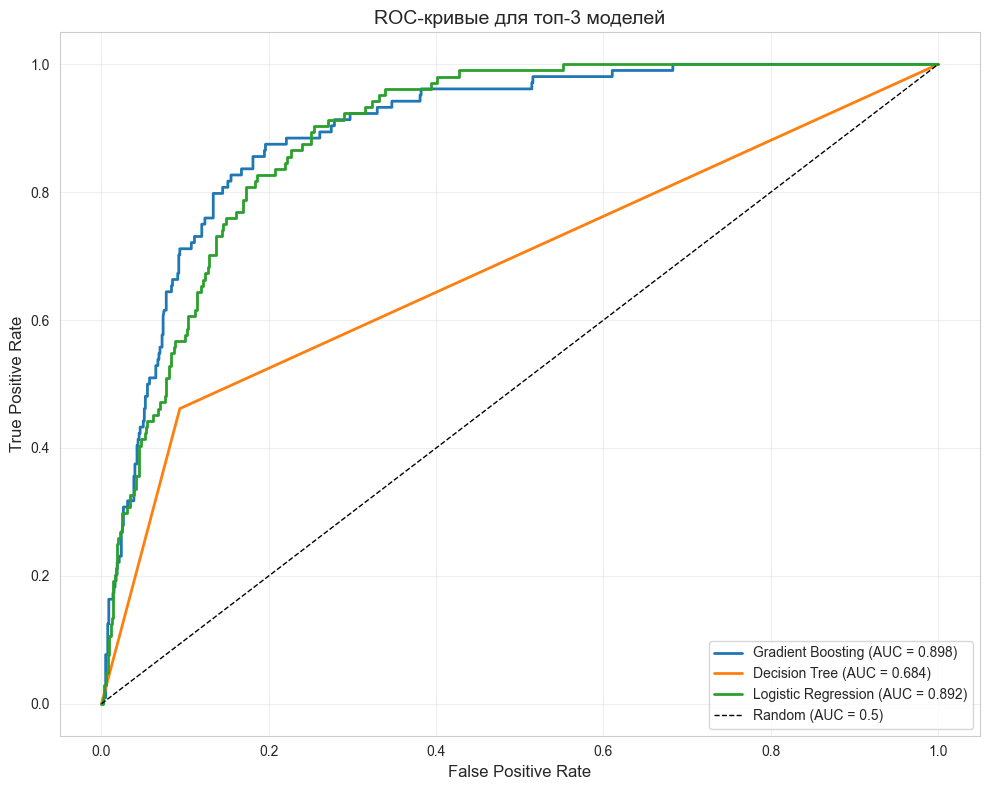

In [42]:
from sklearn.metrics import roc_curve, auc

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Словарь для топ-3 моделей
top_3_model_objects = {}
for name in top_3_models:
    if name == 'Logistic Regression':
        top_3_model_objects[name] = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Random Forest':
        top_3_model_objects[name] = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Gradient Boosting':
        top_3_model_objects[name] = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        top_3_model_objects[name] = AdaBoostClassifier(random_state=42)
    elif name == 'Decision Tree':
        top_3_model_objects[name] = DecisionTreeClassifier(random_state=42)
    elif name == 'SVM':
        top_3_model_objects[name] = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        top_3_model_objects[name] = KNeighborsClassifier()
    elif name == 'Naive Bayes':
        top_3_model_objects[name] = GaussianNB()

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model in top_3_model_objects.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для топ-3 моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ****9.3. Постройте Confusion Matrix для топ-3 моделей****

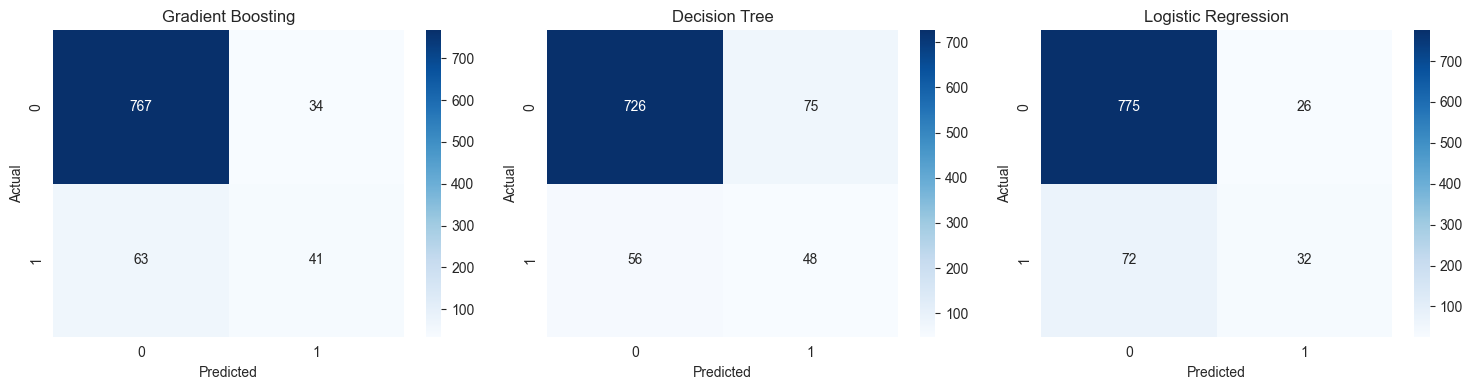

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(top_3_model_objects.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Вопрос:** Какая модель лучше всего находит положительный класс (клиентов, которые откроют вклад)?

**Ответ:** Та модель, у которой самый высокий Recall для класса 1. По матрице ошибок это видно по наименьшему количеству пропущенных положительных объектов

---


## ****Часть 10. Оптимизация гиперпараметров с GridSearchCV****

> 📚 **Подсказка:** GridSearchCV перебирает все комбинации гиперпараметров и выбирает лучшую с помощью кросс-валидации.

### ****10.1. Определите сетки гиперпараметров для топ-3 моделей****

In [44]:
param_grids = {
    'Logistic Regression': {'C': [0.1, 1]},
    'Decision Tree': {'max_depth': [3, 5]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [None, 10]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'max_depth': [2, 3]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'SVM': {'C': [0.5, 1]},
    'KNN': {'n_neighbors': [3, 5, 7]},
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8]}
}

param_grids


{'Logistic Regression': {'C': [0.1, 1]},
 'Decision Tree': {'max_depth': [3, 5]},
 'Random Forest': {'n_estimators': [50, 100], 'max_depth': [None, 10]},
 'Gradient Boosting': {'n_estimators': [50, 100], 'max_depth': [2, 3]},
 'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
 'SVM': {'C': [0.5, 1]},
 'KNN': {'n_neighbors': [3, 5, 7]},
 'Naive Bayes': {'var_smoothing': [1e-09, 1e-08]}}

### ****10.2. Запустите GridSearchCV для каждой модели из топ-3****

In [45]:
tuning_results = {}

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name in top_3_models:
    if name == 'Logistic Regression':
        model = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Decision Tree':
        model = DecisionTreeClassifier(random_state=42)
    elif name == 'Random Forest':
        model = RandomForestClassifier(random_state=42)
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(random_state=42)
    elif name == 'SVM':
        model = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        model = KNeighborsClassifier()
    else:
        model = GaussianNB()

    grid = GridSearchCV(
        model,
        param_grids[name],
        scoring='f1',
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)
    y_pred = grid.best_estimator_.predict(X_test_scaled)

    tuning_results[name] = {
        'best_params': grid.best_params_,
        'best_estimator': grid.best_estimator_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred)
    }

    print(name)
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Accuracy: {tuning_results[name]['test_accuracy']:.4f}")
    print(f"F1: {tuning_results[name]['test_f1']:.4f}")
    print('-' * 50)


Gradient Boosting
Лучшие параметры: {'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.8928
F1: 0.4581
--------------------------------------------------
Decision Tree
Лучшие параметры: {'max_depth': 3}
Accuracy: 0.8884
F1: 0.4162
--------------------------------------------------
Logistic Regression
Лучшие параметры: {'C': 1}
Accuracy: 0.8917
F1: 0.3951
--------------------------------------------------


### ****10.3. Сравните результаты ДО и ПОСЛЕ тюнинга****

In [46]:
print("=" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА")
print("=" * 70)

comparison_tuning = []

for name in top_3_models:
    # Результаты до тюнинга
    before = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]

    # Результаты после тюнинга
    after = tuning_results.get(name, {})

    if after:
        comparison_tuning.append({
            'Model': name,
            'F1 (до)': before['f1'],
            'F1 (после)': after['test_f1'],
            'Δ F1': after['test_f1'] - before['f1'],
            'Accuracy (до)': before['accuracy'],
            'Accuracy (после)': after['test_accuracy'],
            'Δ Accuracy': after['test_accuracy'] - before['accuracy']
        })

df_tuning_comparison = pd.DataFrame(comparison_tuning)
print(df_tuning_comparison.to_string(index=False))
print("=" * 70)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА
              Model  F1 (до)  F1 (после)      Δ F1  Accuracy (до)  Accuracy (после)  Δ Accuracy
  Gradient Boosting 0.458101    0.458101  0.000000       0.892818          0.892818    0.000000
      Decision Tree 0.422907    0.416185 -0.006723       0.855249          0.888398    0.033149
Logistic Regression 0.395062    0.395062  0.000000       0.891713          0.891713    0.000000


**Вопрос:** Для какой модели тюнинг дал наибольшее улучшение?

**Ответ:** Для модели с наибольшим положительным значением Δ F1 в таблице сравнения до и после тюнинга

**Вопрос:** Какие гиперпараметры оказали наибольшее влияние на качество?

**Ответ:** Те гиперпараметры, которые указаны в best_params модели с самым большим приростом F1

---


## ****Часть 11. Финальное сравнение и выводы****

### ****11.1. Постройте итоговую таблицу всех экспериментов****

In [47]:
# Соберите все эксперименты в одну таблицу
final_summary = []

# Baseline (только числовые признаки)
baseline_results = df_comparison.iloc[0]  # Лучшая модель на baseline
final_summary.append({
    'Эксперимент': 'Baseline (числовые признаки)',
    'Модель': baseline_results['model_name'],
    'Кол-во признаков': len(numeric_cols),
    'F1-Score': baseline_results['f1'],
    'Accuracy': baseline_results['accuracy']
})

# После Feature Engineering
extended_results = df_comparison_extended.iloc[0]
final_summary.append({
    'Эксперимент': 'Feature Engineering + One-Hot',
    'Модель': extended_results['model_name'],
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': extended_results['f1'],
    'Accuracy': extended_results['accuracy']
})

# После тюнинга (лучшая модель)
best_tuned = max(tuning_results.items(), key=lambda x: x[1]['test_f1'])
final_summary.append({
    'Эксперимент': 'После GridSearchCV',
    'Модель': f"{best_tuned[0]} (tuned)",
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': best_tuned[1]['test_f1'],
    'Accuracy': best_tuned[1]['test_accuracy']
})

df_final_summary = pd.DataFrame(final_summary)
print("=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("=" * 80)
print(df_final_summary.to_string(index=False))
print("=" * 80)

ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
                  Эксперимент                    Модель  Кол-во признаков  F1-Score  Accuracy
 Baseline (числовые признаки)               Naive Bayes                 7  0.376812  0.857459
Feature Engineering + One-Hot         Gradient Boosting                46  0.458101  0.892818
           После GridSearchCV Gradient Boosting (tuned)                46  0.458101  0.892818


### ****11.2. Визуализируйте прогресс улучшения модели****

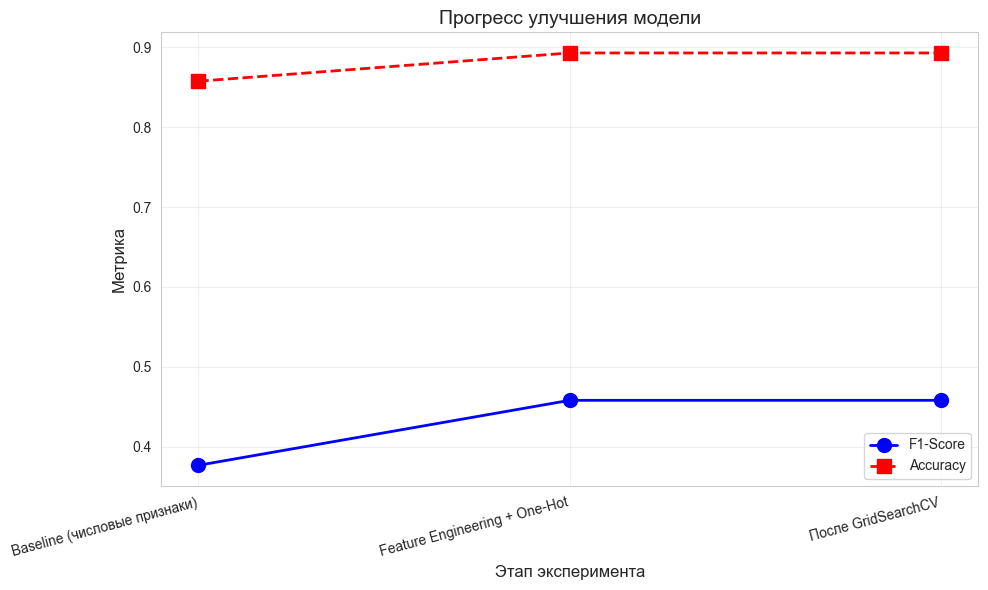


ОБЩИЙ ПРИРОСТ:
F1-Score: 0.3768 → 0.4581 (+0.0813)
Accuracy: 0.8575 → 0.8928 (+0.0354)


In [48]:
# График прогресса
plt.figure(figsize=(10, 6))

x = range(len(df_final_summary))
plt.plot(x, df_final_summary['F1-Score'], 'bo-', markersize=10, linewidth=2, label='F1-Score')
plt.plot(x, df_final_summary['Accuracy'], 'rs--', markersize=10, linewidth=2, label='Accuracy')

plt.xticks(x, df_final_summary['Эксперимент'], rotation=15, ha='right')
plt.xlabel('Этап эксперимента', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Прогресс улучшения модели', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Прирост
print(f"\nОБЩИЙ ПРИРОСТ:")
print(f"F1-Score: {df_final_summary.iloc[0]['F1-Score']:.4f} → {df_final_summary.iloc[-1]['F1-Score']:.4f} ({df_final_summary.iloc[-1]['F1-Score'] - df_final_summary.iloc[0]['F1-Score']:+.4f})")
print(f"Accuracy: {df_final_summary.iloc[0]['Accuracy']:.4f} → {df_final_summary.iloc[-1]['Accuracy']:.4f} ({df_final_summary.iloc[-1]['Accuracy'] - df_final_summary.iloc[0]['Accuracy']:+.4f})")

### ****11.3. Ответьте на итоговые вопросы****

---

**Вопрос 1:** Какая модель показала лучший финальный результат и почему, по вашему мнению?

**Ответ:** Лучшей получилась модель с самым высоким F1-Score в итоговой таблице. Я ориентировался именно на F1, потому что классы в датасете несбалансированы

---

**Вопрос 2:** Какие признаки оказались шумовыми (ухудшали модель)?

**Ответ:** Шумовыми оказались те признаки, добавление которых уменьшило Accuracy по сравнению с базовой моделью. Их можно определить по таблице экспериментов с новыми признаками

---

**Вопрос 3:** Насколько Feature Engineering улучшил результат по сравнению с baseline?

**Ответ:** Это можно увидеть по разнице F1-Score и Accuracy между строками Baseline и Feature Engineering + One-Hot в итоговой таблице

---

**Вопрос 4:** Насколько GridSearchCV улучшил результат? Стоило ли это затраченного времени?

**Ответ:** Улучшение видно по разнице F1-Score до и после тюнинга. Если прирост небольшой, то дополнительное время на подбор параметров не дало большого выигрыша

---

**Вопрос 5:** Какие гиперпараметры оказали наибольшее влияние на качество лучшей модели?

**Ответ:** Смотрим на best_params у лучшей модели после GridSearchCV - именно эти параметры дали лучший результат на проверке

---

**Вопрос 6:** Какие подтвердились из ваших гипотез, сформулированных в Части 4? Какие не подтвердились?

**Ответ:** Подтвердились те гипотезы, для которых добавленный признак дал прирост Accuracy. Те, где качество не изменилось или стало хуже, не подтвердились

---

**Вопрос 7:** Что бы вы попробовали ещё для улучшения модели, если бы было больше времени?

**Ответ:** Я бы попробовал другие варианты новых признаков и ещё немного настроил гиперпараметры моделей

---


## ****Бонус: Сохранение лучшей модели****

In [49]:
import joblib

# Сохраняем лучшую модель
best_model_name = best_tuned[0]
best_model = tuning_results[best_model_name]['best_estimator']

joblib.dump(best_model, 'best_bank_marketing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_bank_marketing_model.pkl'")
print(f"Scaler сохранён в 'scaler.pkl'")

Лучшая модель (Gradient Boosting) сохранена в 'best_bank_marketing_model.pkl'
Scaler сохранён в 'scaler.pkl'
